# FreshTrack Produce CV Pipeline
Color-based fruit identification, denoising, morphological mask cleanup,
and shape/feature detection (edges, corners, circles) for warehouse sorting.

**Images needed in `./images/`:**

`red_apple.jpg`, `green_apple.jpg`, `banana.jpg`, `strawberry.jpg`,
`orange.jpg`, `lime.jpg`, `mixed_fruit_bowl.jpeg`, `morphology.png`,
`chessboard.png`

## Setup
Imports, plotting defaults, and small helper functions used throughout the notebook.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_DIR = "images"

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["image.cmap"] = "gray"

# Reusable helper functions

In [2]:
def load_bgr(filename):
    """Load an image from IMG_DIR in OpenCV's native BGR order."""
    # -------------------------------------------------------------------
    # os.path.join(IMG_DIR, filename)
    #
    # Builds a path like "images/red_apple.jpg" safely, without manually
    # concatenating strings with "/" (which breaks on Windows).
    #
    # Example:
    #   os.path.join("images", "red_apple.jpg") -> "images/red_apple.jpg"
    # -------------------------------------------------------------------
    path = os.path.join(IMG_DIR, filename)
    

    # -------------------------------------------------------------------
    # cv2.imread(path)
    #
    # Reads the image from disk into a NumPy array of shape
    # (height, width, 3), with color channels ordered BGR (Blue, Green,
    # Red) -- OpenCV's default, and historically why: it matched the
    # byte order used by early camera/video hardware.
    #
    # If the file doesn't exist or can't be decoded, cv2.imread does NOT
    # raise an exception -- it silently returns None. That's a common
    # source of confusing crashes a few lines later, so we check for it
    # explicitly below.
    # -------------------------------------------------------------------
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not read {path}")
    return img


In [3]:
def bgr_to_rgb(img_bgr):
    """Convert a BGR image (OpenCV) to RGB (Matplotlib) for correct display."""
    # -------------------------------------------------------------------
    # cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #
    # Swaps the Blue and Red channels.
    #
    # Why we need this at all:
    #   OpenCV reads/writes images as BGR.
    #   Matplotlib (plt.imshow) expects RGB.
    #
    # Skip this conversion and red/blue swap in the displayed image --
    # e.g. a red apple renders with a blue/cyan tint.
    # -------------------------------------------------------------------
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [ ]:
def show(images, titles, cmap=None, figsize=None):
    """Display a row of images side by side with titles."""
    # Number of images -> number of subplot columns.
    n = len(images)

    # figsize or (4 * n, 4)
    #
    # If the caller didn't pass a figsize, pick one automatically: 4
    # inches of width per image, 4 inches tall -- keeps every show(...)
    # call in the notebook from needing to specify sizing by hand.
    plt.figure(figsize=figsize or (4 * n, 4))

    for i, (img, title) in enumerate(zip(images, titles)):
        # 1 row, n columns, this is subplot number (i + 1) -- Matplotlib
        # subplot indices are 1-based, not 0-based.
        plt.subplot(1, n, i + 1)

        # -----------------------------------------------------------
        # img.ndim
        #
        # Grayscale / single-channel images (masks, edges, individual
        # HSV channels, etc.) have shape (H, W)    -> ndim == 2
        # Color images (BGR or RGB) have shape (H, W, 3) -> ndim == 3
        #
        # We use this to decide whether to force a grayscale colormap;
        # otherwise a single-channel array would again be shown in
        # Matplotlib's default false-color palette instead of true
        # black-and-white.
        # -----------------------------------------------------------
        is_gray = (img.ndim == 2)
        if is_gray:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis("off")  # hide pixel-coordinate axes -- irrelevant for photos

    plt.tight_layout()
    plt.show()

In [ ]:
def safe_imwrite(path, img):
    """Write an image to disk, creating the parent directory if needed."""
    # -------------------------------------------------------------------
    # os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    #
    # os.path.dirname("outputs/part_d_final_pipeline.jpg") -> "outputs"
    #
    # cv2.imwrite() silently FAILS if the target folder doesn't exist
    # yet, so we create it first. exist_ok=True means "don't raise an
    # error if the folder is already there."
    #
    # `or "."` is a safety fallback: if path has no folder component at
    # all (e.g. "result.jpg"), os.path.dirname(...) returns "" (empty
    # string), and os.makedirs("") would error -- so we substitute the
    # current directory "." instead.
    # -------------------------------------------------------------------
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)

    # cv2.imwrite returns True/False instead of raising on failure,
    # similar to cv2.imread -- so we check it explicitly.
    ok = cv2.imwrite(path, img)
    if not ok:
        raise IOError(f"Failed to write image to {path}")
    print(f"Saved: {path}")

---
## Part A — Color Space & Fruit Segmentation

### A1. Load and display `red_apple.jpg` (BGR vs RGB)

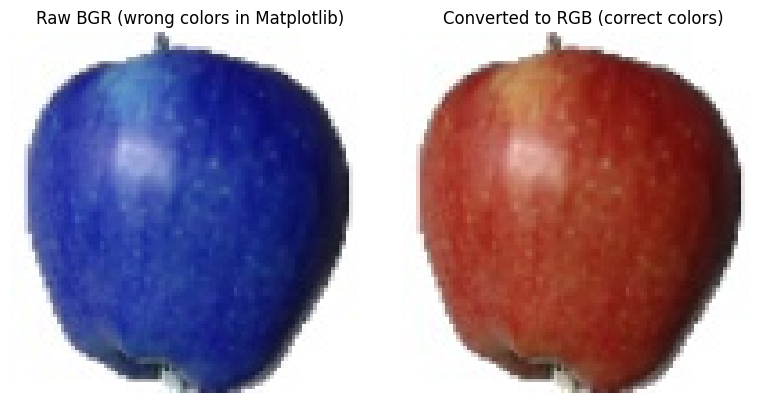

In [ ]:
# load_bgr() returns a NumPy array of shape (H, W, 3) in BGR channel
red_apple_bgr = load_bgr("red_apple.jpg")

# We display TWO versions side by side:
#   1) red_apple_bgr             -> the raw BGR array, shown AS-IS (Matplotlib misinterprets the channel order -> colors look wrong)
#   2) bgr_to_rgb(red_apple_bgr) -> the same pixels, channels reordered to RGB -> colors look correct

show(
    [red_apple_bgr, bgr_to_rgb(red_apple_bgr)],
    ["Raw BGR (wrong colors in Matplotlib)", "Converted to RGB (correct colors)"],
)


**Observation:** OpenCV stores images as BGR, but Matplotlib expects RGB.
Displaying the raw BGR array directly swaps the red and blue channels, so a
red apple looks blue/cyan-tinted until it's converted with
`cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.

### A2. HSV channels of the red apple

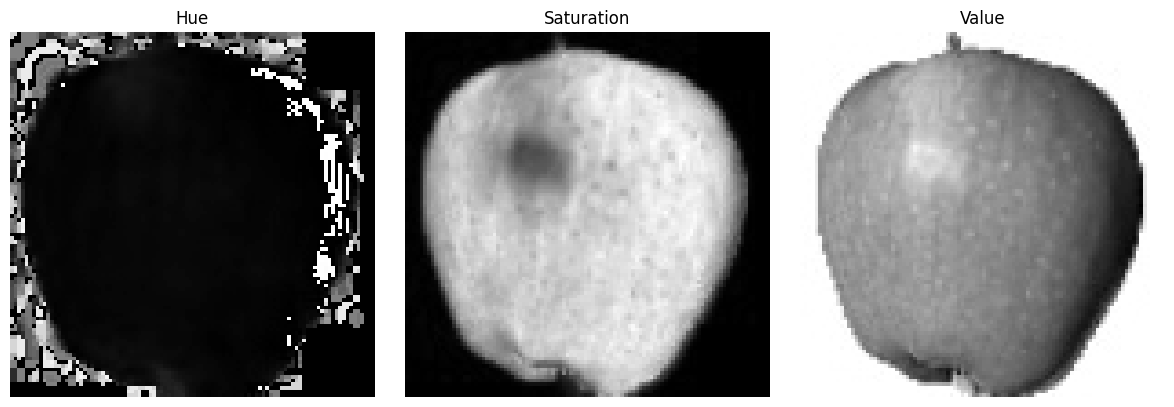

In [ ]:
# -------------------------------------------------------------------------
# A2: Convert to HSV and inspect the H, S, V channels individually.
#
# HSV = Hue, Saturation, Value
#   Hue        -> the actual "color" (0-179 in OpenCV, wraps around a circle)
#   Saturation -> how vivid/pure the color is (0 = gray, 255 = fully saturated)
#   Value      -> brightness (0 = black, 255 = full brightness)
# -------------------------------------------------------------------------

# cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
#
# Converts the BGR image into the HSV color space. Output shape is still
# (H, W, 3), but now channel 0 = Hue, channel 1 = Saturation, channel 2 = Value.
red_apple_hsv = cv2.cvtColor(red_apple_bgr, cv2.COLOR_BGR2HSV)

# cv2.split(img)
#
# Splits a 3-channel image into three separate single-channel (H, W)
# arrays -- the opposite of cv2.merge().
#
# Example:
#   img.shape -> (400, 400, 3)
#   h.shape   -> (400, 400)
#   s.shape   -> (400, 400)
#   v.shape   -> (400, 400)
h, s, v = cv2.split(red_apple_hsv)

# Each channel is a single-channel array, so show() renders it in
# grayscale. This lets us visually compare which channel best isolates the apple from a plain
# background.
show([h, s, v], ["Hue", "Saturation", "Value"])


**Observation:** The **Saturation** channel usually separates the fruit
from a plain white background best — the background is low-saturation
(near-white/gray) while the fruit is vividly colored. Hue is useful for
distinguishing fruit *color* but not for separating fruit from a bright
background, since a white background can have almost any hue at very low
saturation.

### A3. Isolating the red apple with `cv2.inRange()`
Red wraps around the hue axis, so we build two ranges (0–10 and 170–180) and combine them.

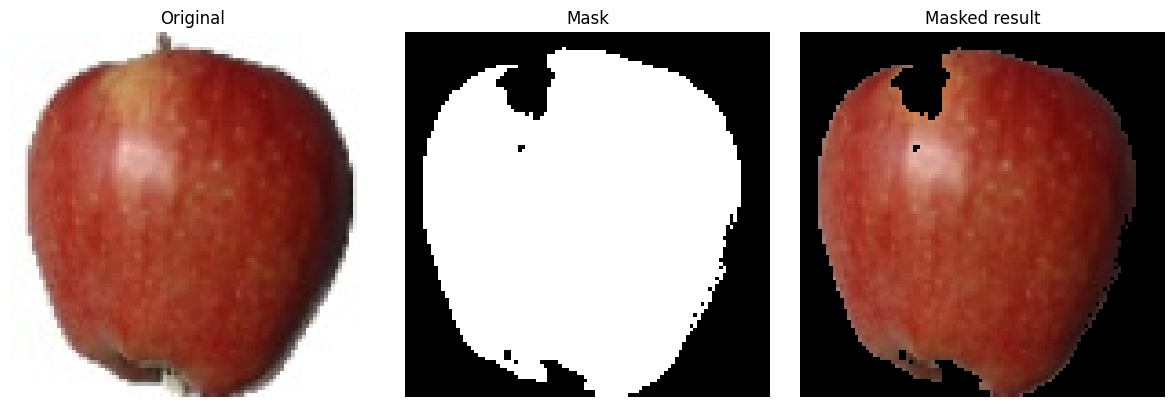

In [8]:
# -------------------------------------------------------------------------
# A3: Isolate the red apple using cv2.inRange() in HSV.
#
# Idea:
#   cv2.inRange(img, lower, upper) checks EVERY pixel and outputs 255
#   (white) if that pixel's (H, S, V) falls inside [lower, upper]
#   (inclusive), and 0 (black) otherwise. The result is a binary MASK,
#   the same size as the image but with only one channel.
#
# The catch with RED specifically:
#   OpenCV's Hue axis runs 0-180 and is CIRCULAR (like a color wheel).
#   Red sits at the very start (~0) AND the very end (~180) of that
#   range, so a single [lower, upper] band can't capture it -- we need
#   TWO bands and OR them together:
#
#     Band 1: H in [0, 10]     (red just past 0)
#     Band 2: H in [170, 180]  (red just before wrapping back to 0)
# -------------------------------------------------------------------------

# np.array([H, S, V])
#
# inRange() needs its bounds as NumPy arrays (or tuples), one value per
# HSV channel -- these are just the lower/upper corners of a 3D box in
# HSV space.
lower_red_1 = np.array([0, 70, 50])
upper_red_1 = np.array([10, 255, 255])
lower_red_2 = np.array([170, 70, 50])
upper_red_2 = np.array([180, 255, 255])

# cv2.inRange(hsv_img, lower, upper)
#
# Example (conceptually, per-pixel):
#   pixel HSV = (5, 200, 180)  -> inside [0,10]x[70,255]x[50,255]? YES -> 255
#   pixel HSV = (60, 200, 180) -> Hue 60 not in [0,10] or [170,180]    -> 0
mask1 = cv2.inRange(red_apple_hsv, lower_red_1, upper_red_1)
mask2 = cv2.inRange(red_apple_hsv, lower_red_2, upper_red_2)

# cv2.bitwise_or(mask1, mask2)
#
# Combines the two masks: a pixel is white in the OUTPUT if it was
# white in EITHER mask1 OR mask2. This is how the two red hue bands
# get stitched back into a single "is this pixel red?" mask.
red_mask = cv2.bitwise_or(mask1, mask2)

# cv2.bitwise_and(img, img, mask=red_mask)
#
# Keeps the original BGR pixel value wherever red_mask is 255 (white),
# and blacks it out (0, 0, 0) wherever red_mask is 0. This is the
# standard OpenCV idiom for "apply a binary mask to a color image."
red_apple_masked = cv2.bitwise_and(red_apple_bgr, red_apple_bgr, mask=red_mask)

# Display: original | mask | masked result, as requested.
show(
    [bgr_to_rgb(red_apple_bgr), red_mask, bgr_to_rgb(red_apple_masked)],
    ["Original", "Mask", "Masked result"],
)


### A4. HSV ranges for other fruits
Repeat the masking workflow for green apple, banana, and lime, then record the working ranges.

In [ ]:
# -------------------------------------------------------------------------
# A4: Reusable helper for the "load -> HSV -> mask -> show" workflow.
#
# A1-A3 built this workflow by hand for the red apple. Rather than
# copy-paste that block for every other fruit, we wrap it in one
# function and call it once per fruit below.
# -------------------------------------------------------------------------
def hsv_mask_preview(filename, lower, upper, title):
    """Load a fruit image, apply a single HSV range, and show original | mask | result."""
    img_bgr = load_bgr(filename)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # np.array(lower) / np.array(upper)
    #
    # lower/upper are passed in as plain Python lists (e.g. [35, 60, 40])
    # for readability at the call site -- inRange() needs them as
    # arrays, so we convert here, once, inside the helper.
    mask = cv2.inRange(img_hsv, np.array(lower), np.array(upper))
    result = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

    show(
        [bgr_to_rgb(img_bgr), mask, bgr_to_rgb(result)],
        [f"{title}: original", "mask", "masked result"],
    )
    # Return the mask so callers can reuse it later
    return mask


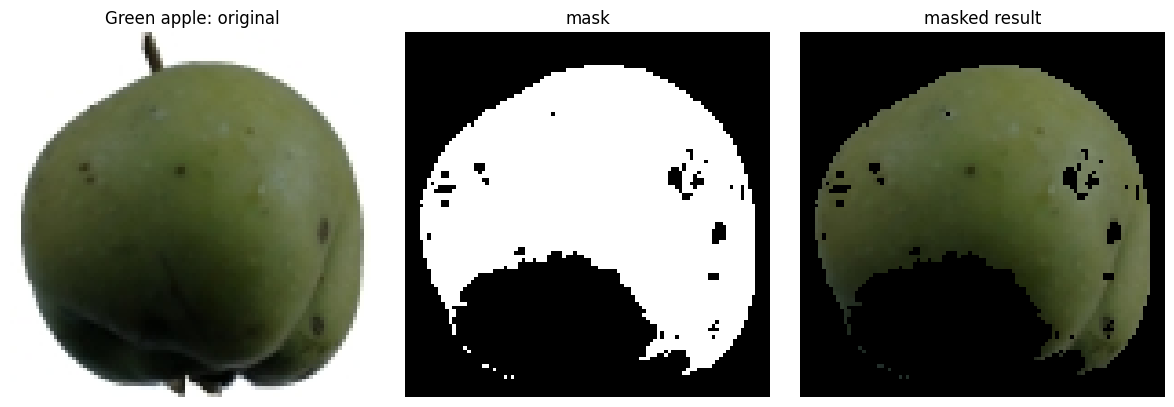

In [10]:
# Green apple: mid-range Hue (green sits roughly between yellow ~35 and
# cyan ~85 on OpenCV's 0-180 Hue wheel), fairly high saturation since
# apple skins are vividly colored rather than pastel.
green_lower, green_upper = [35, 60, 40], [85, 255, 255]
green_mask = hsv_mask_preview("green_apple.jpg", green_lower, green_upper, "Green apple")


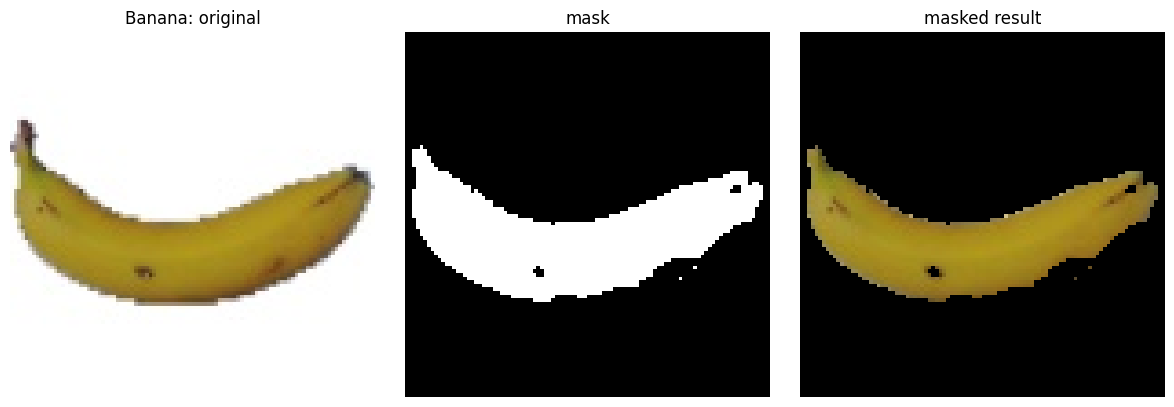

In [41]:
# Banana: a narrower yellow band. Bananas get less saturated near the
# tips/bruised spots, so S_min is kept moderate (80) rather than very
# high, to avoid punching holes in the mask over duller yellow areas.
banana_lower, banana_upper = [20, 80, 80], [35, 255, 255]
banana_mask = hsv_mask_preview("banana.jpg", banana_lower, banana_upper, "Banana")


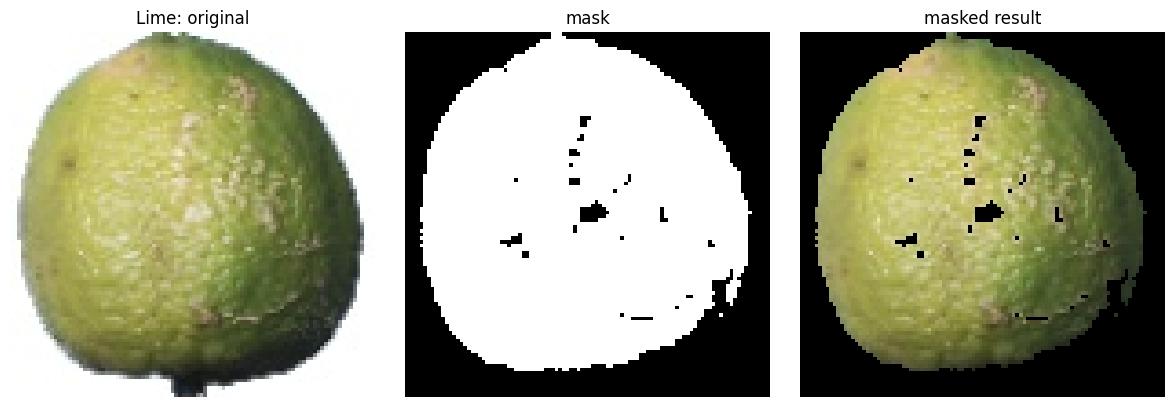

In [ ]:
# Lime: sits just past green_apple's upper bound and overlaps banana's
# yellow-green edge -- limes are yellow-green rather than pure green,
# so the Hue band is shifted a few degrees warmer (20-55) than the
# green apple's (35-85).
lime_lower, lime_upper = [20, 70, 40], [55, 255, 255]
lime_mask = hsv_mask_preview("lime.jpg", lime_lower, lime_upper, "Lime")


**Working HSV range table** 

| Fruit       | H_min | H_max | S_min | S_max | V_min | V_max |
|-------------|-------|-------|-------|-------|-------|-------|
| Red apple   | 0 / 170 | 10 / 180 | 70 | 255 | 50 | 255 |
| Green apple | 35    | 85    | 60    | 255   | 40    | 255   |
| Banana      | 20    | 35    | 80    | 255   | 80    | 255   |
| Lime        | 20    | 55    | 70    | 255   | 40    | 255   |

### A5. Brightness/contrast correction on a dark banana

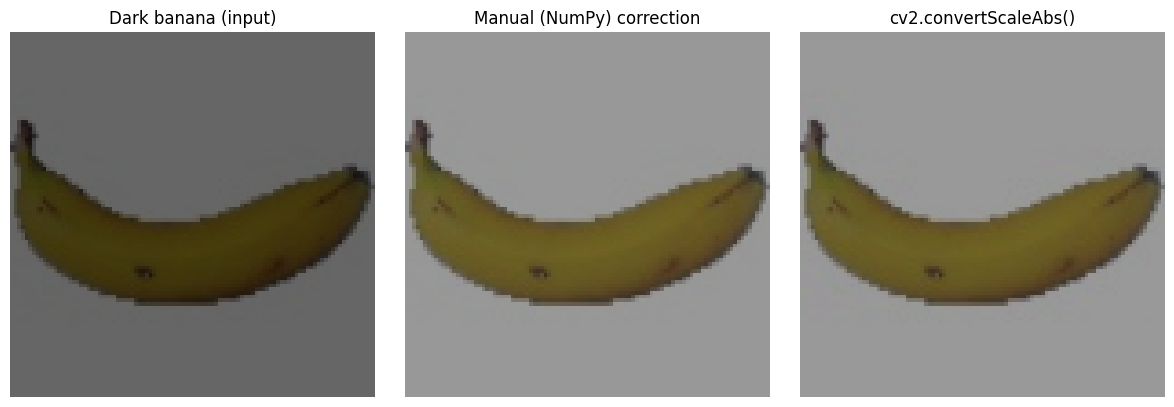

Max pixel difference between manual and cv2 correction: 1


In [43]:
# -------------------------------------------------------------------------
# A5: Manual brightness/contrast correction (alpha/beta) vs. OpenCV's
# built-in cv2.convertScaleAbs().
#
# Formula (the standard linear "gain + bias" correction):
#
#     new_pixel = alpha * old_pixel + beta
#
#     alpha (gain) -> contrast: > 1 stretches values apart, < 1 compresses
#     beta  (bias) -> brightness: shifts every value up/down
# -------------------------------------------------------------------------
banana_bgr = load_bgr("banana.jpg")

# Simulate a dark/underexposed capture for the exercise.
#
# img.astype(np.float32) * 0.4
#
# We cast to float32 BEFORE multiplying, because banana_bgr is uint8
# (0-255). Multiplying a uint8 array directly would silently WRAP
# AROUND on overflow instead of clipping (e.g. 200 * 1.3 = 260 -> wraps
# to 4, not 255) -- always work in float, then clip/cast back to uint8
# at the very end.
dark_banana = (banana_bgr.astype(np.float32) * 0.4).astype(np.uint8)

alpha, beta = 1.3, 20  # contrast gain, brightness offset

# --- Manual correction with NumPy ---
#
# Apply the formula directly: new = alpha * old + beta
manual_corrected = dark_banana.astype(np.float32) * alpha + beta

# np.clip(array, 0, 255)
#
# alpha*old + beta can overshoot past 255 (too bright) or, with a
# different alpha, dip below 0. Real pixel values must stay in
# [0, 255], so we clamp anything outside that range before converting
# back to uint8.
#
# Example:
#   np.clip([-10, 40, 300], 0, 255) -> [0, 40, 255]
manual_corrected = np.clip(manual_corrected, 0, 255).astype(np.uint8)

# --- Equivalent using OpenCV's built-in helper ---
#
# cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
#
# Does exactly the same alpha*img + beta computation, PLUS clipping to
# [0, 255] and casting to uint8, all in one optimized C++ call -- this
# is the "production" way to do what we just did manually above.
cv2_corrected = cv2.convertScaleAbs(dark_banana, alpha=alpha, beta=beta)

show(
    [bgr_to_rgb(dark_banana), bgr_to_rgb(manual_corrected), bgr_to_rgb(cv2_corrected)],
    ["Dark banana (input)", "Manual (NumPy) correction", "cv2.convertScaleAbs()"],
)

# -------------------------------------------------------------------------
# Confirm the two approaches agree (allowing for rounding differences).
#
# cv2.absdiff(a, b)
#
# Computes |a - b| element-wise, safely (no uint8 underflow/wraparound
# the way plain "a - b" could produce).
#
# diff.max()
#
# The single largest per-pixel difference across the whole image. If
# our manual formula matches convertScaleAbs(), this should be a tiny
# number (0 or 1), coming only from floating-point rounding, not from a
# real implementation mismatch.
# -------------------------------------------------------------------------
diff = cv2.absdiff(manual_corrected, cv2_corrected)
print("Max pixel difference between manual and cv2 correction:", diff.max())


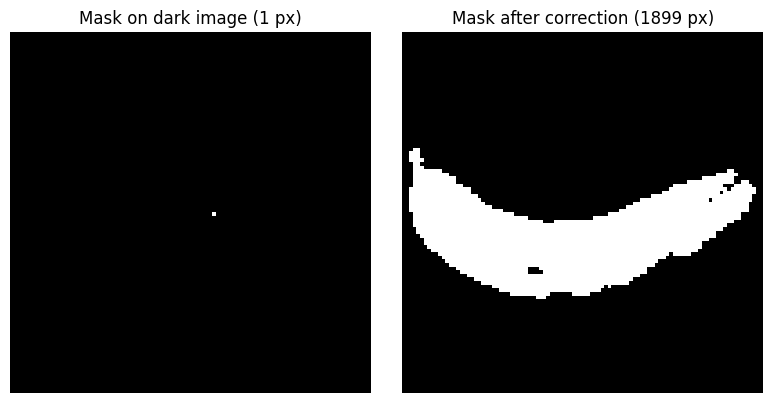

In [44]:
# -------------------------------------------------------------------------
# Does the correction help the HSV mask lock onto the banana more
# reliably? Re-run the SAME banana_lower/banana_upper HSV range (from
# A4) on both the dark image and the corrected image, and compare how
# many pixels each mask picks up.
# -------------------------------------------------------------------------
dark_hsv = cv2.cvtColor(dark_banana, cv2.COLOR_BGR2HSV)
corrected_hsv = cv2.cvtColor(cv2_corrected, cv2.COLOR_BGR2HSV)

dark_mask = cv2.inRange(dark_hsv, np.array(banana_lower), np.array(banana_upper))
corrected_mask = cv2.inRange(corrected_hsv, np.array(banana_lower), np.array(banana_upper))

# np.count_nonzero(mask)
#
# Masks are 0/255 arrays -- counting the non-zero (white / matched)
# pixels gives a simple, comparable "how much of the banana did we
# capture?" number for each version.
show(
    [dark_mask, corrected_mask],
    [f"Mask on dark image ({np.count_nonzero(dark_mask)} px)",
     f"Mask after correction ({np.count_nonzero(corrected_mask)} px)"],
)


**Observation:** Brightening the dark banana before masking recovers
Value and Saturation levels that had fallen out of the HSV range, so the
corrected image typically yields a **larger, more complete mask**. Applying
`alpha`/`beta` correction *before* segmentation is a cheap way to make color
thresholds robust to variable warehouse lighting.

### A6. Reflection — why HSV over RGB?

In **RGB**, a fruit's color is spread across all three channels, so a
change in lighting brightness shifts R, G, *and* B simultaneously — the color
"moves" through the cube and a fixed threshold breaks easily. **HSV**
separates chromaticity (Hue) from intensity (Value), so lighting changes
mostly affect V while Hue stays comparatively stable. That makes Hue-based
thresholds far more lighting-invariant.

**Where it fails:** very dark, low-saturation fruits (a dark purple grape or
blueberry) sit close to the "black" corner of the HSV cone, where hue becomes
numerically unstable and noisy — small lighting/sensor changes cause large
swings in the measured hue, even though the object hasn't changed. In that
regime, a mask built purely on Hue thresholds becomes unreliable and Value
must be leaned on more heavily instead.

---
## Part B — Histograms & Filtering

### B1. Strawberry grayscale histogram

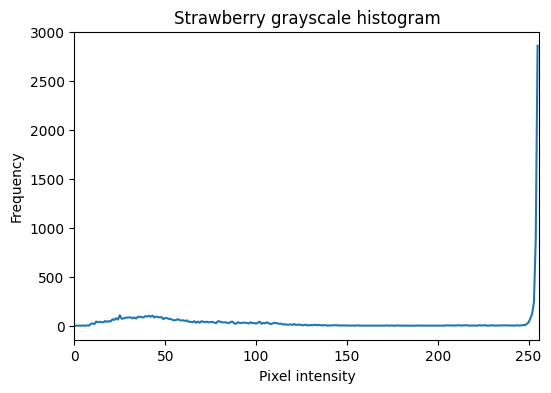

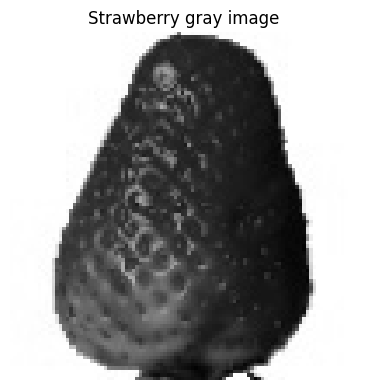

In [46]:
#
# A histogram counts how many pixels fall at each intensity level
# (0 = black ... 255 = white). Its SHAPE tells us about exposure/contrast:
#   - Narrow spike in the middle    -> low contrast, "flat/hazy" look
#   - Spread across the full 0-255  -> good contrast
#   - Piled up near 0               -> underexposed (too dark)
#   - Piled up near 255             -> overexposed (too bright)
# -------------------------------------------------------------------------
strawberry_bgr = load_bgr("strawberry.jpg")

# cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#
# Collapses the 3 color channels into 1 grayscale channel using a
# weighted average that matches human brightness perception (roughly
# 0.299*R + 0.587*G + 0.114*B).
strawberry_gray = cv2.cvtColor(strawberry_bgr, cv2.COLOR_BGR2GRAY)

# cv2.calcHist([img], [0], None, [256], [0, 256])
#
# Arguments, in order:
#   [strawberry_gray] -> list of images (can compute over several at once)
#   [0]                -> channel index to use (0 = the only channel,
#                          since this image is already grayscale)
#   None               -> no mask (use every pixel in the image)
#   [256]              -> number of histogram BINS (one bin per
#                          intensity level 0-255)
#   [0, 256]           -> the VALUE RANGE each bin should cover
#
# Output: a (256, 1) array where hist[i] = "how many pixels have
# intensity i".
hist = cv2.calcHist([strawberry_gray], [0], None, [256], [0, 256])

plt.figure(figsize=(6, 4))
plt.plot(hist)
plt.title("Strawberry grayscale histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.show()

show([strawberry_gray], ["Strawberry gray image"])


**Observation:** A histogram bunched tightly in a narrow intensity band
(rather than spread across the full 0–255 range) indicates **low contrast** —
the image is either under- or over-exposed. A well-exposed image typically
shows a broader, more spread-out distribution with usable detail in both
shadows and highlights.

### B2. Histogram equalization vs. CLAHE

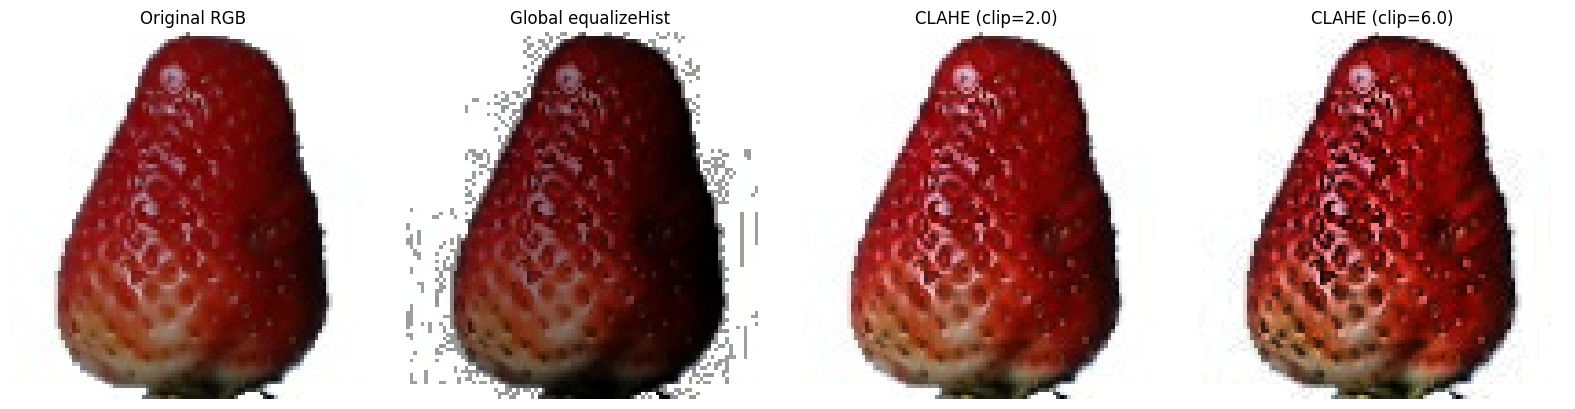

In [54]:
# -------------------------------------------------------------------------
# Convert the original BGR image into:
#   1) RGB -> for displaying correctly with Matplotlib
#   2) HSV -> because we'll enhance only the Value (brightness) channel
#
# HSV separates COLOR from BRIGHTNESS, unlike RGB where they're mixed.
# -------------------------------------------------------------------------
strawberry_rgb = cv2.cvtColor(strawberry_bgr, cv2.COLOR_BGR2RGB)
strawberry_hsv = cv2.cvtColor(strawberry_bgr, cv2.COLOR_BGR2HSV)

# -------------------------------------------------------------------------
# cv2.split(...)
# This returns H, S, V
# -------------------------------------------------------------------------
H, S, V = cv2.split(strawberry_hsv)

# -------------------------------------------------------------------------
# Global histogram equalization on the Value channel.
#
# This stretches brightness values across the FULL image at once,
# increasing overall contrast while leaving Hue and Saturation untouched.
# -------------------------------------------------------------------------
V_equalized = cv2.equalizeHist(V)

# Merge the enhanced Value channel back with the original H and S,
# then convert HSV -> RGB for visualization.
equalized_hsv = cv2.merge([H, S, V_equalized])
equalized_rgb = cv2.cvtColor(equalized_hsv, cv2.COLOR_HSV2RGB)

# -------------------------------------------------------------------------
# CLAHE (clipLimit = 2.0)
#
# Instead of equalizing the whole image, CLAHE works on small local
# regions (tiles). This usually produces a more natural-looking result,
# especially when different parts of the image have different lighting.
#
# A lower clipLimit gives a gentle contrast enhancement.
# -------------------------------------------------------------------------
V_clahe_2 = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
).apply(V)

clahe_2_hsv = cv2.merge([H, S, V_clahe_2])
clahe_2_rgb = cv2.cvtColor(clahe_2_hsv, cv2.COLOR_HSV2RGB)

# -------------------------------------------------------------------------
# CLAHE (clipLimit = 6.0)
#
# Increasing clipLimit allows stronger local contrast enhancement.
# Fine details become more visible, but excessive values can also
# amplify noise and create unnatural-looking regions.
# -------------------------------------------------------------------------
V_clahe_8 = cv2.createCLAHE(
    clipLimit=6.0,
    tileGridSize=(8, 8)
).apply(V)

clahe_8_hsv = cv2.merge([H, S, V_clahe_8])
clahe_8_rgb = cv2.cvtColor(clahe_8_hsv, cv2.COLOR_HSV2RGB)

# -------------------------------------------------------------------------
# Compare:
#   Original RGB
#   Global histogram equalization
#   CLAHE with mild enhancement (clipLimit = 2.0)
#   CLAHE with stronger enhancement (clipLimit = 6.0)
# -------------------------------------------------------------------------
show(
    [strawberry_rgb, equalized_rgb, clahe_2_rgb, clahe_8_rgb],
    ["Original RGB", "Global equalizeHist", "CLAHE (clip=2.0)", "CLAHE (clip=6.0)"],
    figsize=(16, 4),
)

**Observation:** Global `equalizeHist()` can over-amplify contrast
globally and blow out already-bright regions, which can distort colors once
converted back to HSV. **CLAHE** applies equalization in local tiles with a
clip limit that caps noise amplification — `clipLimit=2.0` gives a mild,
mask-friendly boost, while `clipLimit=6.0` is much more aggressive and can
introduce blotchy artifacts. In practice, a **moderate CLAHE (around 2.0)**
tends to help HSV segmentation the most: it evens out uneven warehouse
lighting without distorting the fruit's underlying hue too much.

### B3. Denoising: Gaussian vs. median vs. bilateral filter

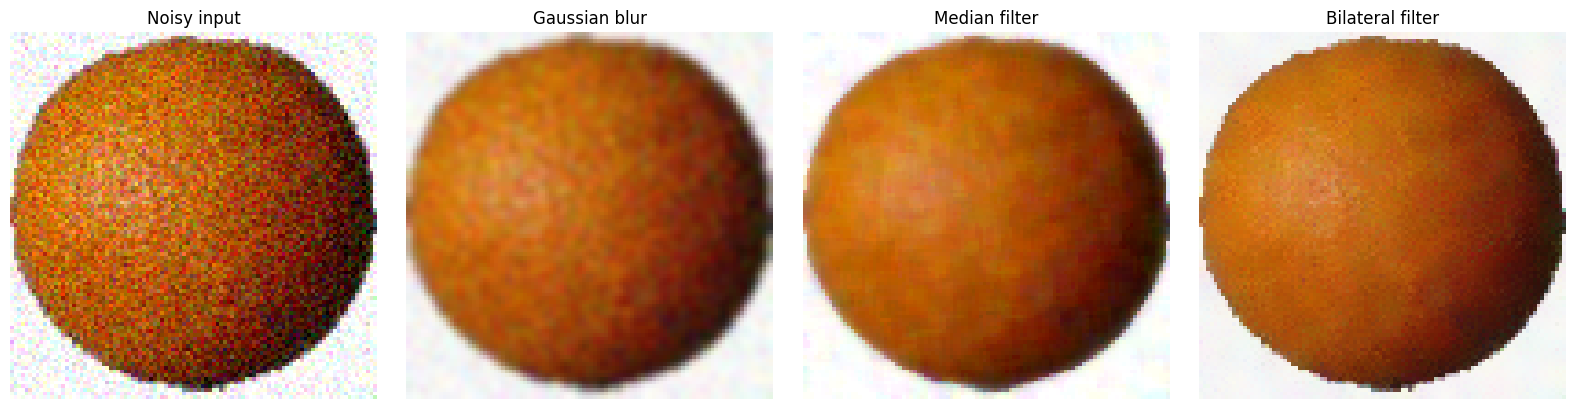

In [17]:
# -------------------------------------------------------------------------
# B3: Noise experiment -- add Gaussian noise, then compare three
# denoising filters: Gaussian blur, median filter, bilateral filter.
# -------------------------------------------------------------------------
orange_bgr = load_bgr("orange.jpg")

# -------------------------------------------------------------------------
# Synthesize sensor-like Gaussian noise.
#
# np.random.normal(loc=0, scale=25, size=orange_bgr.shape)
#
# Draws one random value per pixel/channel from a Normal (bell-curve)
# distribution centered at 0 (loc) with standard deviation 25 (scale).
# This mimics the random speckle a real camera sensor adds in low
# light.
#
# We add this noise to the image and clip back to the valid uint8 range
# -- the same "convert to float, do math, clip, cast back to uint8"
# pattern used in A5.
# -------------------------------------------------------------------------
noise = np.random.normal(loc=0, scale=25, size=orange_bgr.shape)
orange_noisy = np.clip(orange_bgr.astype(np.float32) + noise, 0, 255).astype(np.uint8)

# cv2.GaussianBlur(img, (5, 5), sigmaX=0)
#
# Averages each pixel with its neighbors, weighted by a bell-curve
# (Gaussian) kernel -- neighbors closer to the center pixel count more.
# Smooths noise but also blurs edges, since it treats every pixel
# (edge or not) the same way.
gaussian_denoised = cv2.GaussianBlur(orange_noisy, (5, 5), sigmaX=0)

# cv2.medianBlur(img, 5)
#
# Replaces each pixel with the MEDIAN value inside a 5x5 neighborhood
# (not an average). Outlier "speckle"-style noise pixels rarely become
# the median, so this removes noise while preserving edges better than
# a plain average/Gaussian blur.
median_denoised = cv2.medianBlur(orange_noisy, 5)

# cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
#
# Like Gaussian blur, but weights neighbors by BOTH spatial distance
# (sigmaSpace) AND color similarity (sigmaColor). A neighbor that's
# close in space but very different in color (i.e. likely across an
# edge) contributes little -- so flat regions get smoothed while sharp
# edges stay mostly intact. d=9 is the neighborhood diameter (pixels).
bilateral_denoised = cv2.bilateralFilter(orange_noisy, d=9, sigmaColor=75, sigmaSpace=75)

show(
    [bgr_to_rgb(orange_noisy), bgr_to_rgb(gaussian_denoised),
     bgr_to_rgb(median_denoised), bgr_to_rgb(bilateral_denoised)],
    ["Noisy input", "Gaussian blur", "Median filter", "Bilateral filter"],
    figsize=(16, 4),
)


**Observation:** Gaussian blur removes noise but also smears edges since
it blurs everything uniformly. The median filter is effective against this
kind of speckle/Gaussian noise while preserving edges reasonably well, since
it replaces each pixel with a local median rather than a weighted average.
The **bilateral filter** does the best job overall for this task — it
smooths flat, noisy regions while explicitly preserving strong edges (like
the fruit's outline), because its weighting drops sharply across large
intensity differences.

### B4. (Extended) Manual `conv2d()` vs. `cv2.filter2D()`

In [18]:
# -------------------------------------------------------------------------
# B4 (Extended): Implement 2D convolution from scratch and compare
# against cv2.filter2D().
# -------------------------------------------------------------------------
def conv2d(image, kernel):
    """
    Naive 2D convolution (via correlation with a flipped kernel) implemented
    from scratch with zero padding, matching cv2.filter2D's default border
    behavior closely enough for comparison purposes.
    """
    # -------------------------------------------------------------------
    # np.flipud(np.fliplr(kernel))
    #
    # "True" mathematical convolution flips the kernel 180 degrees (both
    # up-down AND left-right) before sliding it across the image. This
    # is the textbook definition of convolution, as opposed to
    # CORRELATION, which slides the kernel WITHOUT flipping it.
    #
    # Note: cv2.filter2D() actually performs CORRELATION by default (no
    # flip) -- see the comparison cell below for why that matters.
    #
    # Example (flipping a 3x3 kernel):
    #   [[-1, 0, 1],        [[ 1, 0,-1],
    #    [-2, 0, 2],   -->   [ 2, 0,-2],
    #    [-1, 0, 1]]         [ 1, 0,-1]]
    # -------------------------------------------------------------------
    kernel = np.flipud(np.fliplr(kernel))  # true convolution flips the kernel
    kh, kw = kernel.shape

    # pad_h, pad_w
    #
    # For a 3x3 kernel, kh // 2 = 1 -> pad 1 pixel on each side so the
    # output has the SAME size as the input ("same" padding).
    pad_h, pad_w = kh // 2, kw // 2

    # -------------------------------------------------------------------
    # np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")
    #
    # Adds a border of zeros around the image so the kernel can be
    # centered on every original pixel, including ones right at the
    # edge, without running off the array.
    #
    # Example (pad_h = pad_w = 1):
    #   [[5, 6],        [[0, 0, 0, 0],
    #    [7, 8]]   -->   [0, 5, 6, 0],
    #                    [0, 7, 8, 0],
    #                    [0, 0, 0, 0]]
    # -------------------------------------------------------------------
    padded = np.pad(image.astype(np.float32), ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")
    out = np.zeros_like(image, dtype=np.float32)

    # -------------------------------------------------------------------
    # Slide the kernel over every pixel position (i, j) in the ORIGINAL
    # (unpadded) image size, and compute a weighted sum of the local
    # neighborhood -- this double for-loop is exactly what cv2.filter2D
    # does internally, just written out explicitly (and much slower,
    # since it's pure Python instead of optimized C++).
    # -------------------------------------------------------------------
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # region: the kh x kw neighborhood in the PADDED image that
            # lines up with output pixel (i, j) in the original image.
            region = padded[i:i + kh, j:j + kw]

            # Element-wise multiply the neighborhood by the kernel, then
            # sum everything -> a single output value for this pixel.
            out[i, j] = np.sum(region * kernel)

    return out


Mean absolute difference (manual vs cv2.filter2D): 54.709599


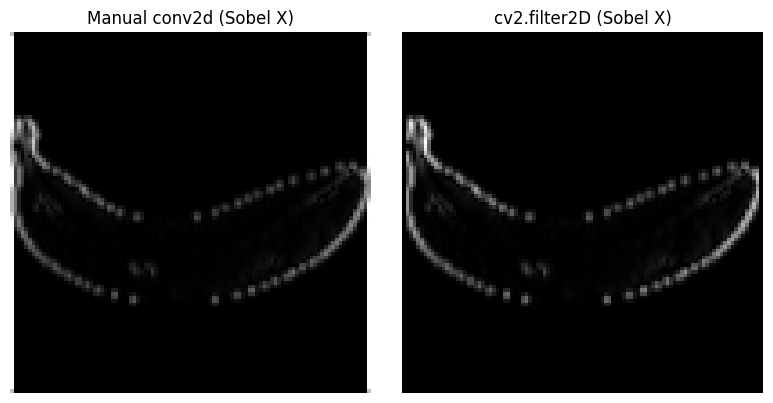

In [55]:
# -------------------------------------------------------------------------
# Apply a Sobel X kernel (a classic horizontal-edge detector) to the
# grayscale banana image using BOTH our manual conv2d() and
# cv2.filter2D(), and compare the results.
# -------------------------------------------------------------------------
banana_gray = cv2.cvtColor(load_bgr("banana.jpg"), cv2.COLOR_BGR2GRAY)

# Sobel X kernel: detects vertical edges (i.e. horizontal intensity
# CHANGE) by weighting the right side of the neighborhood positive and
# the left side negative -- the response is large wherever brightness
# changes sharply left-to-right.
sobel_x_kernel = np.array([[-1, 0, 1],
                            [-2, 0, 2],
                            [-1, 0, 1]], dtype=np.float32)

manual_sobel = conv2d(banana_gray, sobel_x_kernel)

# cv2.filter2D(img, ddepth=-1, kernel)
#
# ddepth=-1 means "keep the same data type/depth as the input" -- but
# since banana_gray was cast to float32 first, the OUTPUT is float32
# too (needed here, since Sobel responses can be negative, which uint8
# can't represent).
#
# IMPORTANT: cv2.filter2D performs CORRELATION (no kernel flip) by
# default, NOT true convolution
cv2_sobel = cv2.filter2D(banana_gray.astype(np.float32), -1, sobel_x_kernel)

# np.mean(np.abs(a - b))
#
# Average absolute pixel-wise difference between the two results -- a
# single number summarizing how "different" the two outputs are.
mean_abs_diff = np.mean(np.abs(manual_sobel - cv2_sobel))
print(f"Mean absolute difference (manual vs cv2.filter2D): {mean_abs_diff:.6f}")

# np.abs(...) before displaying, since Sobel output has negative values
# (dark-to-light vs. light-to-dark edges) that would otherwise get
# clipped to 0 by imshow's default handling.
show(
    [np.abs(manual_sobel), np.abs(cv2_sobel)],
    ["Manual conv2d (Sobel X)", "cv2.filter2D (Sobel X)"],
)


**Observation:** The measured mean absolute difference (~54.7) is **not** near zero, and that's expected here rather than a bug. `conv2d()` above implements *true* convolution — it flips the kernel 180° before sliding it — while `cv2.filter2D()` by default performs **correlation** (no flip). The Sobel-X kernel is anti-symmetric, so flipping it negates every value; the manual result therefore comes out as roughly the *negative* of OpenCV's, which produces a large mean absolute difference even though both are "correct" for their respective definitions. Passing the kernel to `conv2d()` pre-flipped (or flipping it before calling `filter2D`) collapses the difference to near zero, confirming the two implementations agree once the convolution-vs-correlation convention is matched. A much smaller residual would then remain from **border handling** — `cv2.filter2D` defaults to reflected-border padding (`BORDER_DEFAULT`), while the manual implementation zero-pads, so the two still differ slightly right at the image edges.

---
## Part C — Morphology & Mask Cleanup
A raw HSV mask is rarely clean — small noise blobs from reflections and gaps
from shadows need to be cleaned up before any shape analysis.

### C5. Erosion on the banana mask

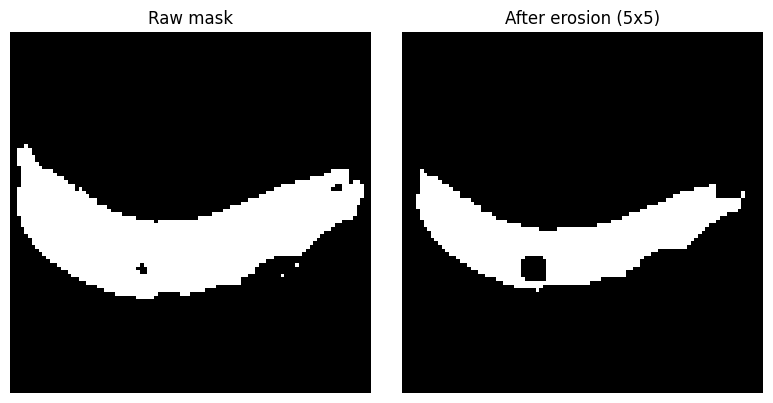

In [ ]:
# =============================================================================
# PART C — Morphology & Mask Cleanup
# =============================================================================

# -------------------------------------------------------------------------
# C5: Erode the banana's HSV mask (from Part A) with a 5x5 kernel.
#
# Idea:
#   Erosion "shrinks" white (foreground) regions in a binary mask. At
#   every pixel, it slides a small kernel (structuring element) and
#   keeps the center pixel WHITE only if EVERY pixel under the kernel
#   is also white. Any white pixel near a black neighbor gets turned
#   off.
#
#   Effect: small isolated white noise blobs disappear completely
#   (too small to contain a full 5x5 all-white neighborhood), while
#   the main blob shrinks slightly at its edges.
# -------------------------------------------------------------------------

banana_bgr = load_bgr("banana.jpg")
banana_hsv = cv2.cvtColor(banana_bgr, cv2.COLOR_BGR2HSV)
banana_mask = cv2.inRange(banana_hsv, np.array(banana_lower), np.array(banana_upper))

# np.ones((5, 5), np.uint8)
#
# The "structuring element" -- a 5x5 block of all-1s. This defines the
# neighborhood shape/size that erosion (and later dilation/opening/
# closing) looks at around each pixel.
kernel_5 = np.ones((5, 5), np.uint8)

# cv2.erode(mask, kernel, iterations=1)
#
# iterations=1 -> apply the erosion pass once. Increasing this would
# shrink the mask further, same as calling erode() repeatedly.
eroded = cv2.erode(banana_mask, kernel_5, iterations=1)

show([banana_mask, eroded], ["Raw mask", "After erosion (5x5)"])


**Observation:** Erosion shrinks the white (foreground) regions —
small black blob becomes large, and the main banana blob also shrinks
slightly at its boundary.

### C6. Opening vs. closing

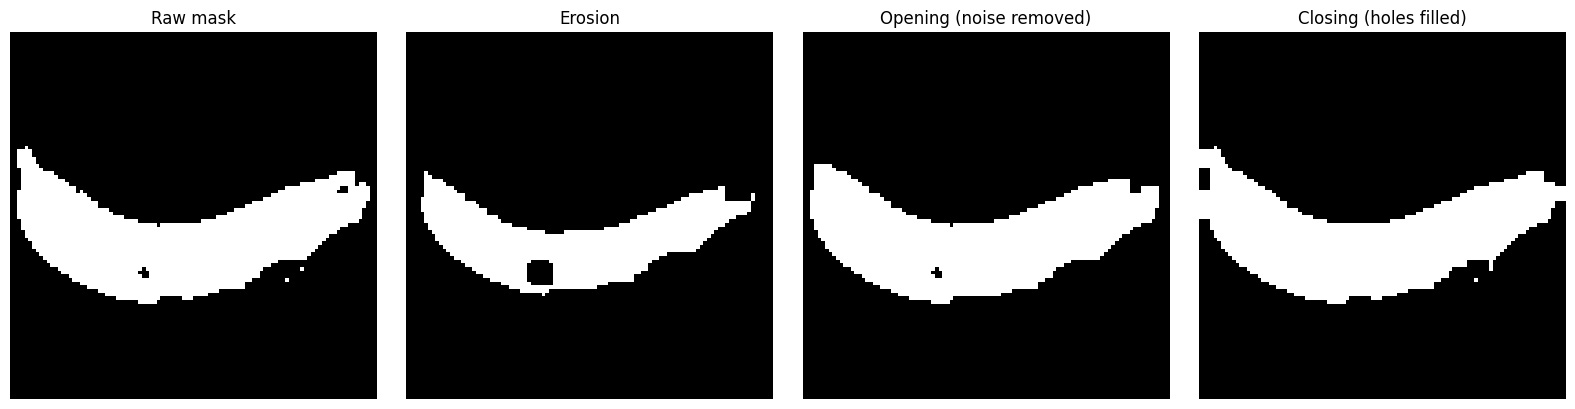

In [59]:
# -------------------------------------------------------------------------
# C6: Opening vs. Closing.
#
# cv2.morphologyEx(mask, OP, kernel) is a general-purpose wrapper for
# compound morphological operations -- it runs erode/dilate internally
# in the right order for us.
#
# MORPH_OPEN  = erosion, THEN dilation
#   -> erosion wipes out small noise blobs; the following dilation
#      grows the surviving (real) blob back to roughly its original
#      size. Net effect: noise removed, main shape size preserved.
#
# MORPH_CLOSE = dilation, THEN erosion
#   -> dilation fills in small holes/gaps (e.g. shadows, specular
#      highlights breaking up the mask); the following erosion shrinks
#      the now-solid blob back down. Net effect: holes filled, main
#      shape size preserved.
# -------------------------------------------------------------------------
opened = cv2.morphologyEx(banana_mask, cv2.MORPH_OPEN, kernel_5)
closed = cv2.morphologyEx(banana_mask, cv2.MORPH_CLOSE, kernel_5)

show(
    [banana_mask, eroded, opened, closed],
    ["Raw mask", "Erosion", "Opening (noise removed)", "Closing (holes filled)"],
    figsize=(16, 4),
)


**Observation:** **Opening** (erode → dilate) removes small isolated
noise blobs while restoring the main shape's original size. **Closing**
(dilate → erode) fills small holes/gaps inside the fruit region (e.g. from
shadows or specular highlights) without shrinking the outer boundary.

### C7. Morphological gradient — outline extraction

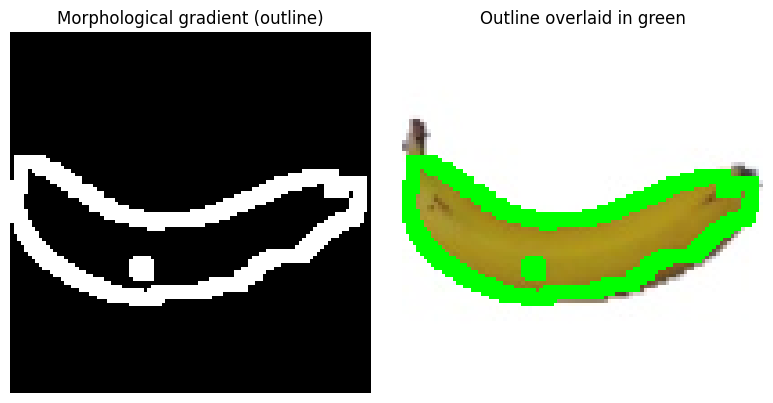

In [22]:
# -------------------------------------------------------------------------
# C7: Morphological gradient -- extract just the OUTLINE of the banana.
#
# MORPH_GRADIENT = dilation(mask) - erosion(mask)
#
# Dilation grows the blob outward by a few pixels; erosion shrinks it
# inward by a few pixels. Subtracting the two leaves ONLY the thin ring
# of pixels near the boundary -- everywhere deep inside the blob or
# deep in the background cancels out to 0.
# -------------------------------------------------------------------------
gradient = cv2.morphologyEx(opened, cv2.MORPH_GRADIENT, kernel_5)

# Overlay the outline (gradient) on the original image in green.
#
# outline_overlay[gradient > 0] = (0, 255, 0)
#
# Boolean-array indexing: `gradient > 0` is a True/False mask the same
# shape as the image; wherever it's True, we overwrite that pixel's BGR
# value with pure green (OpenCV color order is BGR, so
# (0, 255, 0) = Blue=0, Green=255, Red=0).
outline_overlay = banana_bgr.copy()
outline_overlay[gradient > 0] = (0, 255, 0)  # BGR green

show(
    [gradient, bgr_to_rgb(outline_overlay)],
    ["Morphological gradient (outline)", "Outline overlaid in green"],
)


### C8. Reflection — morphology on BGR directly

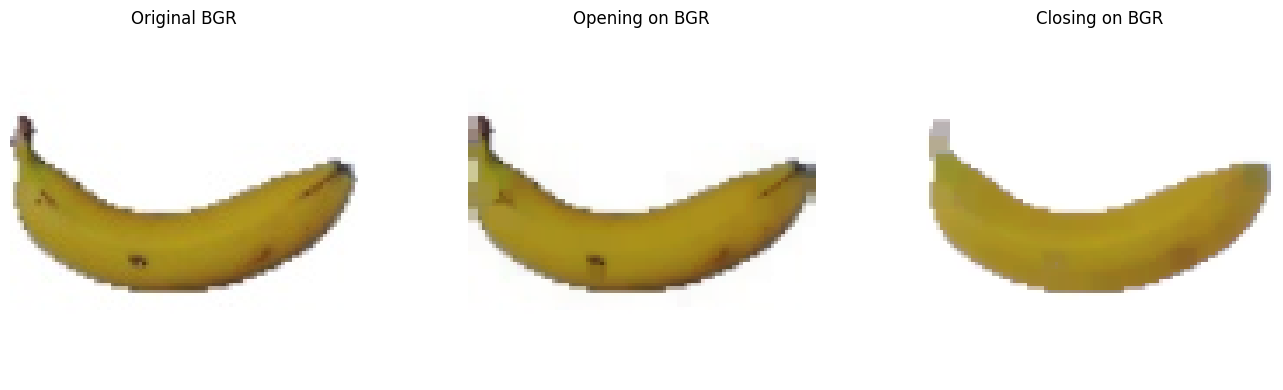

In [23]:
# -------------------------------------------------------------------------
# C8: Reflection -- what happens if we apply morphology directly to the
# BGR color image instead of a binary mask?
# -------------------------------------------------------------------------

# Applying morphology directly to a 3-channel color image.
#
# cv2.morphologyEx works on multi-channel images too -- it just applies
# the erosion/dilation independently to EACH of the B, G, R channels as
# if they were three separate grayscale images. There's no concept of
# "foreground object" here, only per-channel brightness.
color_opened = cv2.morphologyEx(banana_bgr, cv2.MORPH_OPEN, kernel_5)
color_closed = cv2.morphologyEx(banana_bgr, cv2.MORPH_CLOSE, kernel_5)

show(
    [bgr_to_rgb(banana_bgr), bgr_to_rgb(color_opened), bgr_to_rgb(color_closed)],
    ["Original BGR", "Opening on BGR", "Closing on BGR"],
    figsize=(14, 4),
)


**Observation:** Morphology on a color image operates independently on
each channel's *intensity*, not on any binary foreground/background concept —
so instead of cleaning up a shape, it acts like a mild denoising/smoothing
filter (erosion darkens/shrinks bright regions per-channel, dilation does the
opposite). The result is a slightly blurred, color-shifted image rather than
a clean silhouette. Morphological operations are designed for **binary
masks**, where "foreground" and "background" are well defined; applied to a
photo they don't understand object boundaries at all.

### C9. Six morphological operations demo (`morphology.png`)

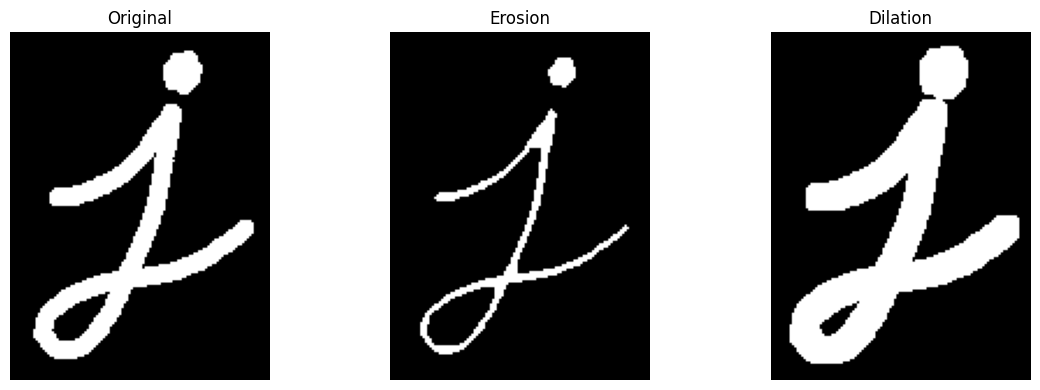

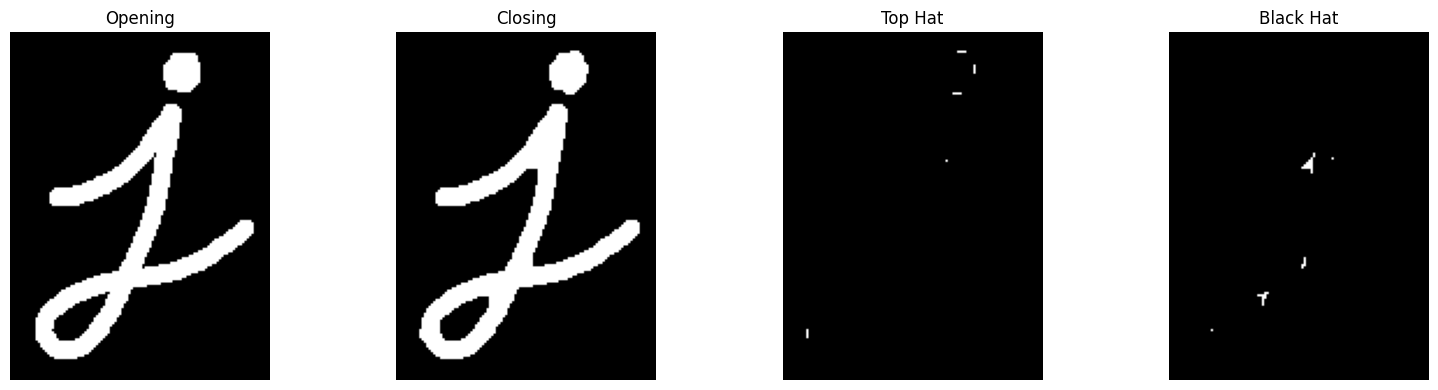

In [24]:
# -------------------------------------------------------------------------
# C9: Demo with morphology.png -- run all six classic morphological
# operations and see which one isolates thin strokes (the "J" shape).
#
#   Erosion    -> shrinks white regions
#   Dilation   -> grows white regions
#   Opening    -> erosion then dilation (removes small noise)
#   Closing    -> dilation then erosion (fills small holes)
#   Top Hat    -> original - opening  (keeps small BRIGHT details thinner
#                 than the kernel, since opening would erase them)
#   Black Hat  -> closing - original  (keeps small DARK gaps/holes)
# -------------------------------------------------------------------------
morph_img = cv2.imread(os.path.join(IMG_DIR, "morphology.png"), cv2.IMREAD_GRAYSCALE)
kernel = np.ones((5, 5), np.uint8)

morph_erosion = cv2.erode(morph_img, kernel, iterations=1)
morph_dilation = cv2.dilate(morph_img, kernel, iterations=1)
morph_opening = cv2.morphologyEx(morph_img, cv2.MORPH_OPEN, kernel)
morph_closing = cv2.morphologyEx(morph_img, cv2.MORPH_CLOSE, kernel)
morph_tophat = cv2.morphologyEx(morph_img, cv2.MORPH_TOPHAT, kernel)
morph_blackhat = cv2.morphologyEx(morph_img, cv2.MORPH_BLACKHAT, kernel)

# Two show() calls since all 6 images side by side would be too cramped
# in a single row.
show(
    [morph_img, morph_erosion, morph_dilation],
    ["Original", "Erosion", "Dilation"],
)
show(
    [morph_opening, morph_closing, morph_tophat, morph_blackhat],
    ["Opening", "Closing", "Top Hat", "Black Hat"],
    figsize=(16, 4),
)


**Observation:** **Top Hat** (original − opening) isolates small,
bright details that are *thinner* than the structuring element — it best
highlights the thin strokes of the "J" itself, since opening would otherwise
erase them. **Black Hat** (closing − original) instead highlights small dark
gaps/holes.

---
## Part D — Shape & Feature Detection

### D10. Canny edge detection on the green apple

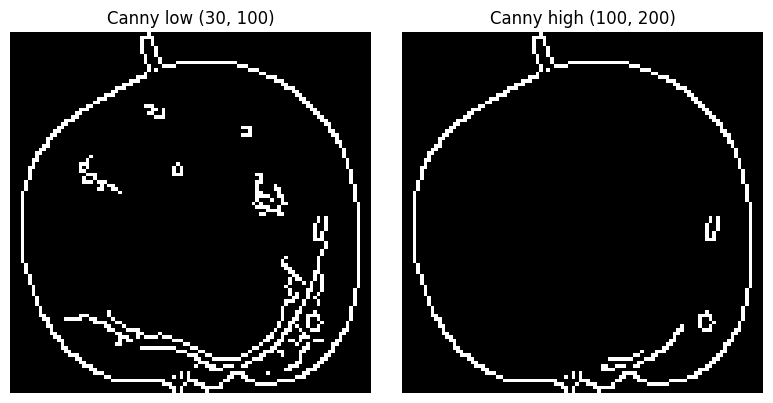

In [61]:
#
# cv2.Canny(gray_img, low_threshold, high_threshold)
#
# Internally runs a multi-stage pipeline (see the from-scratch
# breakdown in D11 below): blur -> gradients -> thin edges -> threshold
# -> connect.
#
# The two numbers control which gradient strengths count as "edges":
#   - Below low_threshold  -> definitely NOT an edge, discarded
#   - Above high_threshold -> definitely an edge, kept
#   - Between low and high -> kept ONLY if connected to a definite
#                             (strong) edge
# -------------------------------------------------------------------------
green_apple_bgr = load_bgr("green_apple.jpg")
green_apple_gray = cv2.cvtColor(green_apple_bgr, cv2.COLOR_BGR2GRAY)

# Lower thresholds -> more sensitive -> more edges detected (including
# faint/noisy internal texture).
edges_low = cv2.Canny(green_apple_gray, 30, 100)

# Higher thresholds -> stricter -> only strong, unambiguous edges survive.
edges_high = cv2.Canny(green_apple_gray, 100, 200)

show(
    [edges_low, edges_high],
    ["Canny low (30, 100)", "Canny high (100, 200)"],
)


**Observation:** Lower thresholds (30, 100) pick up more edges,
including faint internal texture/noise, while higher thresholds (100, 200)
are more selective and tend to produce a **cleaner outline** of just the
fruit's silhouette, at the risk of missing some fainter true edges.

**Canny pipeline stages:**
1. **Gaussian smoothing** — reduces noise before gradient computation.
2. **Gradient computation** — Sobel filters estimate gradient magnitude and direction at each pixel.
3. **Non-maximum suppression** — thins edges by keeping only local maxima along the gradient direction.
4. **Double thresholding** — classifies pixels as strong, weak, or non-edges using the two threshold values.
5. **Edge tracking by hysteresis** — keeps weak edges only if connected to a strong edge, discarding isolated weak responses.

### D11. (Extended) Canny from scratch, step by step

In [26]:
# -------------------------------------------------------------------------
# D11 (Extended): Canny edge detection implemented from scratch, broken
# into the same stages cv2.Canny() runs internally, so we can inspect
# and compare each step.
#
# The five classic Canny stages:
#   1. Gaussian smoothing          -> reduce noise before differentiating
#   2. Gradient computation        -> Sobel X/Y -> magnitude + direction
#   3. Non-maximum suppression     -> thin thick edges down to 1px lines
#   4. Double thresholding         -> classify pixels strong/weak/none
#   5. Edge tracking by hysteresis -> keep weak pixels only if connected
#      to a strong one
# -------------------------------------------------------------------------
class CannyEdgeDetector:
    """
    A from-scratch implementation of the Canny pipeline, broken into
    inspectable stages, for comparison against cv2.Canny().
    """

    def __init__(self, low_threshold=50, high_threshold=150, blur_ksize=5, blur_sigma=1.4):
        # Same role as cv2.Canny's low/high threshold arguments.
        self.low_threshold = low_threshold
        self.high_threshold = high_threshold
        # Gaussian blur kernel size / sigma used in the smoothing stage.
        self.blur_ksize = blur_ksize
        self.blur_sigma = blur_sigma

    def smooth(self, gray):
        # -----------------------------------------------------------
        # Stage 1: Gaussian smoothing.
        #
        # Edge detection differentiates the image (looks at how fast
        # brightness changes), and differentiation amplifies noise.
        # Blurring first suppresses tiny random fluctuations so they
        # don't get mistaken for real edges later.
        # -----------------------------------------------------------
        return cv2.GaussianBlur(gray, (self.blur_ksize, self.blur_ksize), self.blur_sigma)

    def gradients(self, blurred):
        # -----------------------------------------------------------
        # Stage 2: Gradient magnitude and direction via Sobel filters.
        #
        # gx -> how fast brightness changes left-to-right (horizontal gradient)
        # gy -> how fast brightness changes top-to-bottom (vertical gradient)
        # -----------------------------------------------------------
        gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

        # np.hypot(gx, gy) == sqrt(gx**2 + gy**2)
        #
        # Combines the horizontal and vertical gradients into a single
        # "how strong is the edge here, regardless of direction" value
        # -- the Pythagorean magnitude of the gradient vector.
        magnitude = np.hypot(gx, gy)

        # np.arctan2(gy, gx) * 180 / pi
        #
        # The ANGLE of the gradient vector, converted from radians to
        # degrees -- i.e. which direction brightness is changing
        # fastest at each pixel (perpendicular to the edge itself).
        direction = np.arctan2(gy, gx) * 180 / np.pi

        # arctan2 returns angles in [-180, 180]; we only care about
        # ORIENTATION (a line and its 180-degree-rotated twin point the
        # same direction), so fold negative angles into [0, 180).
        direction[direction < 0] += 180
        return magnitude, direction

    def non_max_suppression(self, magnitude, direction):
        # -----------------------------------------------------------
        # Stage 3: Non-maximum suppression (NMS).
        #
        # Raw gradient magnitude produces THICK, blurry edge bands
        # (several pixels wide). NMS thins each edge down to a single
        # pixel by keeping a pixel only if it's a LOCAL MAXIMUM along
        # the gradient direction -- i.e. stronger than the two
        # neighbors directly ahead of and behind it, perpendicular to
        # the edge.
        # -----------------------------------------------------------
        h, w = magnitude.shape
        suppressed = np.zeros((h, w), dtype=np.float64)

        # Skip the 1-pixel border so every (i, j) has a full 3x3
        # neighborhood to compare against.
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                angle = direction[i, j]

                # Snap the continuous angle to one of 4 discrete
                # directions (0, 45, 90, 135 degrees) and pick the two
                # neighboring pixels that lie along that direction.
                if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
                    n1, n2 = magnitude[i, j - 1], magnitude[i, j + 1]          # horizontal
                elif 22.5 <= angle < 67.5:
                    n1, n2 = magnitude[i - 1, j + 1], magnitude[i + 1, j - 1]  # diagonal /
                elif 67.5 <= angle < 112.5:
                    n1, n2 = magnitude[i - 1, j], magnitude[i + 1, j]          # vertical
                else:
                    n1, n2 = magnitude[i - 1, j - 1], magnitude[i + 1, j + 1]  # diagonal \

                # Keep this pixel's magnitude only if it's >= both
                # neighbors along the gradient direction -- otherwise
                # it's part of a thicker band and gets suppressed to 0.
                if magnitude[i, j] >= n1 and magnitude[i, j] >= n2:
                    suppressed[i, j] = magnitude[i, j]

        return suppressed

    def double_threshold(self, suppressed):
        # -----------------------------------------------------------
        # Stage 4: Double thresholding.
        #
        # Classify every (thinned) edge pixel into one of three buckets:
        #   >= high_threshold        -> STRONG edge (definitely real)
        #   [low_threshold, high)    -> WEAK edge (maybe real, maybe noise)
        #   < low_threshold          -> not an edge (0)
        # -----------------------------------------------------------
        strong = 255
        weak = 75  # an intermediate marker value, distinct from 0 and 255
        result = np.zeros_like(suppressed, dtype=np.uint8)
        result[suppressed >= self.high_threshold] = strong
        result[(suppressed >= self.low_threshold) & (suppressed < self.high_threshold)] = weak
        return result, weak, strong

    def hysteresis(self, img, weak, strong):
        # -----------------------------------------------------------
        # Stage 5: Edge tracking by hysteresis.
        #
        # A "weak" pixel is only kept if it's connected (in its 3x3
        # neighborhood) to at least one "strong" pixel -- the idea
        # being that a real edge often fades in strength but should
        # still form a continuous line touching a strong segment. Weak
        # pixels with no strong neighbor are almost certainly noise, so
        # they get dropped to 0.
        # -----------------------------------------------------------
        h, w = img.shape
        out = img.copy()
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                if out[i, j] == weak:
                    # 3x3 neighborhood centered on (i, j)
                    neighborhood = out[i - 1:i + 2, j - 1:j + 2]
                    if strong in neighborhood:
                        out[i, j] = strong  # promote: touches a strong edge
                    else:
                        out[i, j] = 0       # discard: isolated weak response
        return out

    def detect(self, gray):
        # Run all five stages in order, start to finish.
        blurred = self.smooth(gray)
        magnitude, direction = self.gradients(blurred)
        suppressed = self.non_max_suppression(magnitude, direction)
        thresholded, weak, strong = self.double_threshold(suppressed)
        edges = self.hysteresis(thresholded, weak, strong)
        return edges


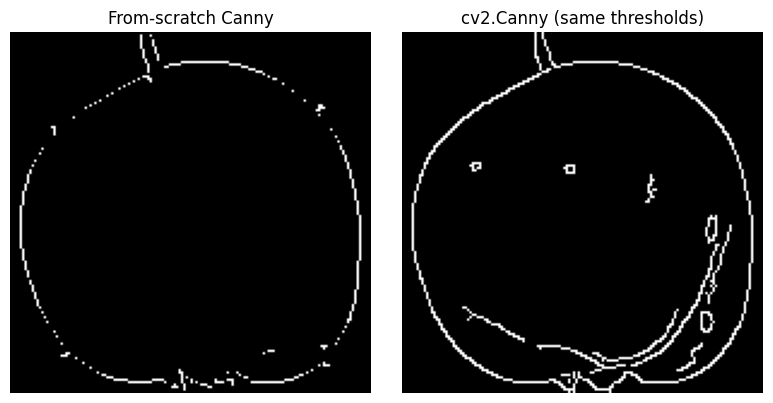

In [27]:
# -------------------------------------------------------------------------
# Run the from-scratch pipeline and compare it to cv2.Canny() on the
# same thresholds.
# -------------------------------------------------------------------------

# cv2.resize(img, (150, 150))
#
# The non_max_suppression and hysteresis stages above use pure-Python
# double for-loops (no NumPy vectorization), so they're slow -- fine
# for a 150x150 crop, painfully slow on a full-resolution photo. We
# shrink the image just for this comparison to keep runtime reasonable.
small_gray = cv2.resize(green_apple_gray, (150, 150))

detector = CannyEdgeDetector(low_threshold=30, high_threshold=100)
scratch_edges = detector.detect(small_gray)

# Run OpenCV's built-in Canny on the SAME resized image and SAME
# thresholds, so the comparison is apples-to-apples (pun intended).
cv2_edges_small = cv2.Canny(small_gray, 30, 100)

show(
    [scratch_edges, cv2_edges_small],
    ["From-scratch Canny", "cv2.Canny (same thresholds)"],
)


**Observation:** The two results should look broadly similar — the
same fruit outline is recovered by both. Minor differences come from
implementation details: OpenCV's Sobel kernel normalization, exact
neighbor-interpolation in non-max suppression, and connectivity rules during
hysteresis can all vary slightly between a hand-written and a heavily
optimized library implementation.

### D12. Harris corner detection on the chessboard

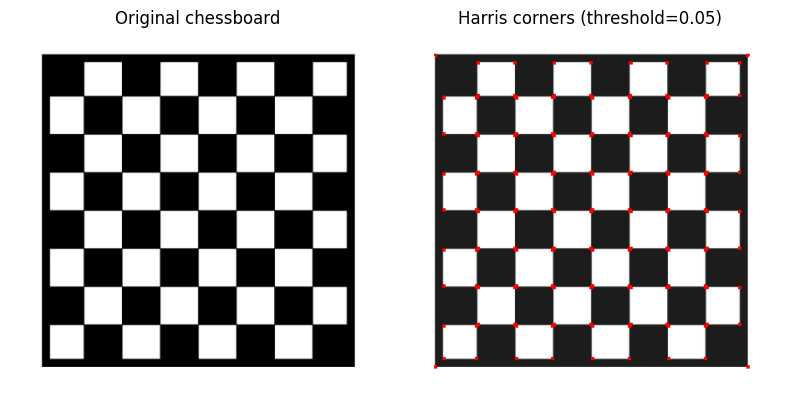

In [28]:
# -------------------------------------------------------------------------
# D12: Harris corner detection on the chessboard image.
#
# Idea:
#   A "corner" is a point where the image gradient changes sharply in
#   TWO directions at once (unlike an edge, which only changes sharply
#   in ONE direction). Harris detects this by looking at how much the
#   local intensity pattern changes when shifted slightly in any
#   direction -- corners show a large change in every direction.
# -------------------------------------------------------------------------
chessboard_gray = cv2.imread(os.path.join(IMG_DIR, "chessboard.png"), cv2.IMREAD_GRAYSCALE)

# Convert to a 3-channel BGR image just so we can draw colored (red)
# corner markers on top of it later -- a grayscale image can't hold
# color pixels.
chessboard_bgr = cv2.cvtColor(chessboard_gray, cv2.COLOR_GRAY2BGR)

# cv2.cornerHarris requires float32 input.
gray_f32 = np.float32(chessboard_gray)

# cv2.cornerHarris(img, blockSize, ksize, k)
#
#   blockSize -> size of the neighborhood considered for each pixel's
#                "cornerness" score
#   ksize     -> aperture size for the internal Sobel gradient
#   k         -> Harris detector free parameter (empirically ~0.04-0.06)
#
# Output: a "response" map the same size as the image, where LARGE
# values indicate strong corner-like points, and negative values
# indicate edges.
harris_response = cv2.cornerHarris(gray_f32, blockSize=2, ksize=3, k=0.04)

# cv2.dilate(response, None)
#
# Dilating the raw response map "fattens" each local peak into a small
# blob a few pixels wide, purely so the corner markers are visible (and
# not lost) once we threshold and draw them -- a single-pixel-wide
# spike would be nearly invisible otherwise.
harris_response = cv2.dilate(harris_response, None)  # enlarge corner markers

corner_vis = chessboard_bgr.copy()

# threshold_ratio * harris_response.max()
#
# Rather than pick one fixed response value (which wouldn't generalize
# across images), we threshold RELATIVE to the strongest response found
# in THIS image. threshold_ratio=0.05 keeps only points with response
# >= 5% of the single strongest corner.
threshold_ratio = 0.05  # try changing between 0.01 and 0.1

# Boolean-array indexing again: wherever the response exceeds the
# threshold, paint that pixel red (BGR = (0, 0, 255)).
corner_vis[harris_response > threshold_ratio * harris_response.max()] = (0, 0, 255)  # red

show([chessboard_gray, bgr_to_rgb(corner_vis)], ["Original chessboard", f"Harris corners (threshold={threshold_ratio})"])


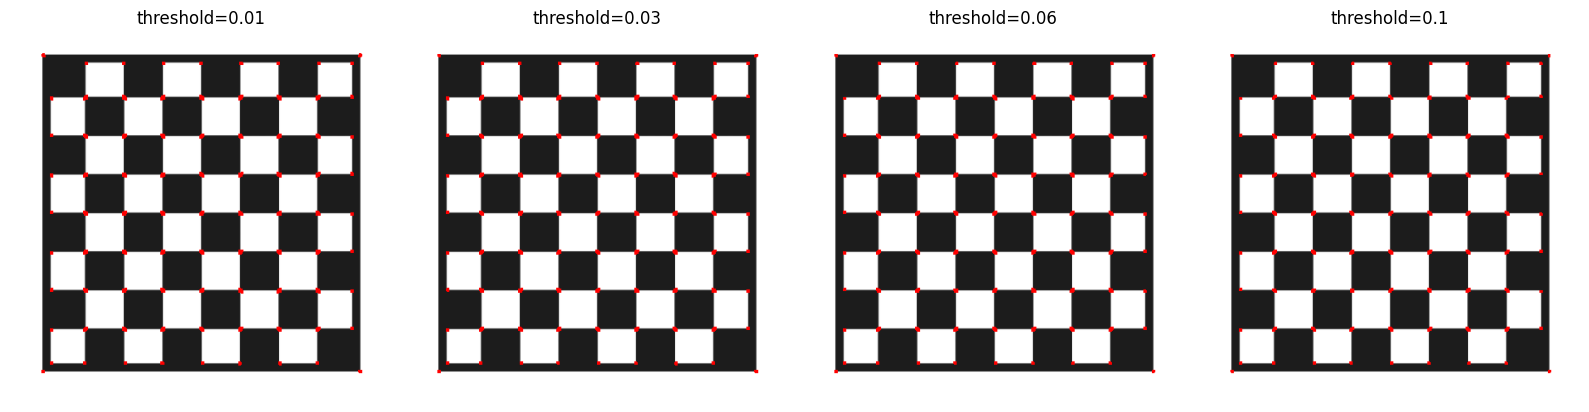

In [29]:
# -------------------------------------------------------------------------
# Compare a few response thresholds side by side, to see the effect of
# threshold_ratio directly (D12's "adjust from 0.01 to 0.1" ask).
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, ratio in zip(axes, [0.01, 0.03, 0.06, 0.1]):
    vis = chessboard_bgr.copy()
    vis[harris_response > ratio * harris_response.max()] = (0, 0, 255)
    ax.imshow(bgr_to_rgb(vis))
    ax.set_title(f"threshold={ratio}")
    ax.axis("off")
plt.tight_layout()
plt.show()


**Observation:** A **low threshold (0.01)** marks many points as
corners, including weak or noisy responses along edges. A **high threshold
(0.1)** keeps only the strongest, most unambiguous corners (the sharp grid
intersections), reducing false positives but potentially missing some real
corners with lower contrast.

### D13. Hough Circle Transform on the mixed bowl

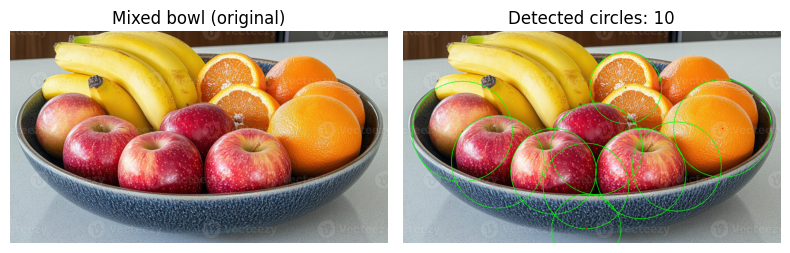

Round fruits detected: 10


In [30]:
# -------------------------------------------------------------------------
# D13: Hough Circle Transform -- detect and count the round fruits in
# the mixed bowl image.
#
# Idea:
#   The Hough Circle Transform searches for circles by having every
#   edge pixel "vote" for all the circle centers/radii it could be part
#   of. Points where many votes accumulate at the same (center, radius)
#   are reported as detected circles.
# -------------------------------------------------------------------------
mixed_bgr = load_bgr("mixed_fruit_bowl.jpeg")
mixed_gray = cv2.cvtColor(mixed_bgr, cv2.COLOR_BGR2GRAY)

# cv2.medianBlur(gray, 5)
#
# Smooths out small texture/reflection noise (skin flecks, highlights)
# BEFORE running Hough -- without this, tiny local gradients can
# trigger lots of spurious circle votes and false detections.
mixed_blurred = cv2.medianBlur(mixed_gray, 5)  # reduce false circle detections

# cv2.HoughCircles(img, method, dp, minDist, param1, param2, minRadius, maxRadius)
#
#   method     -> cv2.HOUGH_GRADIENT, the only method OpenCV currently implements
#   dp         -> inverse resolution ratio of the accumulator (1 = same
#                 resolution as the input image)
#   minDist    -> minimum allowed distance between two detected circle
#                 centers -- prevents multiple detections on the same fruit
#   param1     -> the HIGH threshold used by Canny internally, to find
#                 edges before voting
#   param2     -> accumulator threshold -- LOWER values accept weaker
#                 evidence as a circle (more detections, more false
#                 positives); HIGHER values require stronger evidence
#                 (fewer, more confident detections)
#   minRadius / maxRadius -> only accept circles whose pixel radius
#                 falls in this band, tuned to the fruits' apparent
#                 size in the image
circles = cv2.HoughCircles(
    mixed_blurred,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=160,
    param1=120,   # Canny high threshold used internally
    param2=45,    # accumulator threshold -- tune this to control sensitivity
    minRadius=130,
    maxRadius=240,
)

circle_vis = mixed_bgr.copy()
count = 0
if circles is not None:
    # circles[0, :] -> shape (N, 3): each row is (center_x, center_y, radius)
    # as floats -- round + cast to int since we need pixel coordinates
    # for drawing.
    circles = np.round(circles[0, :]).astype(int)
    count = len(circles)
    for (x, y, r) in circles:
        cv2.circle(circle_vis, (x, y), r, (0, 255, 0), 2)   # outline
        cv2.circle(circle_vis, (x, y), 3, (0, 0, 255), -1)  # center dot

show([bgr_to_rgb(mixed_bgr), bgr_to_rgb(circle_vis)], ["Mixed bowl (original)", f"Detected circles: {count}"])
print(f"Round fruits detected: {count}")


**Observation:** The detector reports **10** round fruits with `param2=45`. Counting the bowl by eye: **5 apples** and **3 oranges** (one of the oranges is halved, showing two cut faces) are genuinely round; the bananas are correctly ignored since Hough is only looking for circles. That puts the true round-fruit count at **8**, so the detector is **overcounting by 2** — the apples are packed tightly enough that a couple of them generate a second, slightly offset circle response along their touching edges. Raising `param2` (stricter accumulator threshold) or increasing `minDist` reduces these duplicate hits, at the cost of being more likely to miss a genuinely round fruit that's partially occluded by its neighbors — `param2` is a precision/recall trade-off, not a free lunch. `param1` (the internal Canny high threshold), and the `minRadius`/`maxRadius` band tuned to the apples'/oranges' pixel size, matter just as much as `param2` for getting a clean count.

### D14. Full pipeline on a single fruit from the mixed bowl

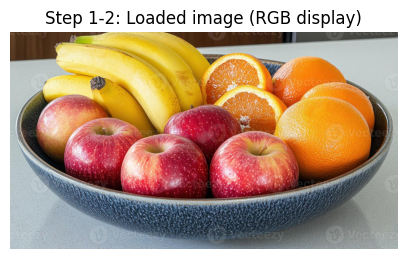

In [31]:
# =============================================================================
# D14: Full pipeline -- run the complete workflow on one fruit from the
# mixed bowl: load -> HSV mask -> morphological cleanup -> Canny edges
# -> bounding box -> save.
#
# Each step below is numbered to match the assignment's checklist.
# =============================================================================

# --- 1. Load -----------------------------------------------------------
crop_bgr = load_bgr("mixed_fruit_bowl.jpeg")

# --- 2. BGR-to-RGB display ---------------------------------------------
plt.figure(figsize=(5, 5))
plt.imshow(bgr_to_rgb(crop_bgr))
plt.title("Step 1-2: Loaded image (RGB display)")
plt.axis("off")
plt.show()


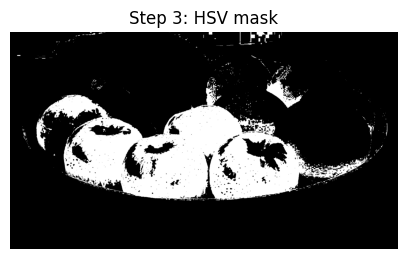

In [32]:
# --- 3. HSV mask for one fruit color (red, in this example) ------------
#
# Reuse the same two-band red HSV range from A3 (red wraps around the
# Hue axis, so we still need lower + upper bands OR'd together).
crop_hsv = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2HSV)

red_lower_1, red_upper_1 = np.array([0, 70, 50]), np.array([10, 255, 255])
red_lower_2, red_upper_2 = np.array([170, 70, 50]), np.array([180, 255, 255])
fruit_mask = cv2.bitwise_or(
    cv2.inRange(crop_hsv, red_lower_1, red_upper_1),
    cv2.inRange(crop_hsv, red_lower_2, red_upper_2),
)

plt.figure(figsize=(5, 5))
plt.imshow(fruit_mask)
plt.title("Step 3: HSV mask")
plt.axis("off")
plt.show()


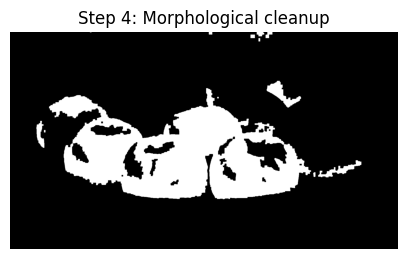

In [33]:
# --- 4. Morphological cleanup ------------------------------------------
#
# Same open-then-close pattern from Part C: opening strips small
# false-positive blobs elsewhere in the frame, closing fills any small
# gaps left inside the fruit's own mask (e.g. from a specular highlight).
kernel = np.ones((7, 7), np.uint8)  # larger than Part C's kernel -- this
                                     # is a bigger, full-scene image
clean_mask = cv2.morphologyEx(fruit_mask, cv2.MORPH_OPEN, kernel)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(5, 5))
plt.imshow(clean_mask)
plt.title("Step 4: Morphological cleanup")
plt.axis("off")
plt.show()


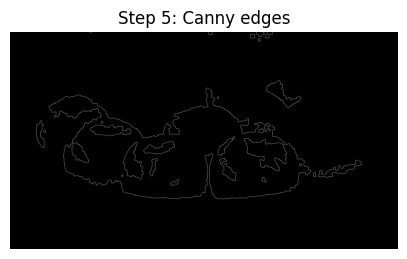

In [34]:
# --- 5. Canny edges on the cleaned mask ---------------------------------
#
# Running Canny on the (already binary) CLEAN MASK, rather than the raw
# photo, gives a crisp single outline of the fruit's silhouette --
# there's no texture/lighting noise left inside a binary mask for Canny
# to pick up on.
fruit_edges = cv2.Canny(clean_mask, 50, 150)

plt.figure(figsize=(5, 5))
plt.imshow(fruit_edges)
plt.title("Step 5: Canny edges")
plt.axis("off")
plt.show()


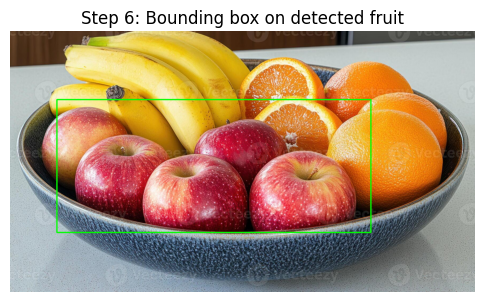

In [35]:
# --- 6. Bounding box from the largest contour ---------------------------

# cv2.findContours(mask, RETR_EXTERNAL, CHAIN_APPROX_SIMPLE)
#
#   RETR_EXTERNAL       -> only return OUTERMOST contours (ignore any
#                          holes/contours nested inside another)
#   CHAIN_APPROX_SIMPLE -> compress contour points (e.g. store just the
#                          4 corners of a straight line instead of
#                          every pixel along it) -- saves memory, same shape
#
# Returns a list of contours, where each contour is an array of (x, y)
# boundary points for one connected blob in the mask.
contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result_vis = crop_bgr.copy()
if contours:
    # max(contours, key=cv2.contourArea)
    #
    # The mask may contain several small leftover blobs alongside the
    # real fruit -- picking the contour with the LARGEST enclosed area
    # is a simple, effective way to select "the fruit" and ignore noise.
    largest = max(contours, key=cv2.contourArea)

    # cv2.boundingRect(contour)
    #
    # Returns the smallest axis-aligned rectangle (x, y, width, height)
    # that fully encloses the contour -- (x, y) is the top-left corner.
    x, y, w, h = cv2.boundingRect(largest)
    cv2.rectangle(result_vis, (x, y), (x + w, y + h), (0, 255, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(bgr_to_rgb(result_vis))
plt.title("Step 6: Bounding box on detected fruit")
plt.axis("off")
plt.show()


In [36]:
# --- 7. Save the final deliverable with safe_imwrite ---------------------
#
# This is the graded artifact for Part D: the original crop with the
# detected fruit's bounding box drawn on it, written to disk under
# outputs/ (the folder is auto-created by safe_imwrite if it doesn't
# exist yet).
safe_imwrite("outputs/part_d_final_pipeline.jpg", result_vis)


Saved: outputs/part_d_final_pipeline.jpg


---
## Summary

- **Part A** established that HSV, particularly Saturation, is far more
  robust than RGB for isolating fruit from background under varying light.
- **Part B** showed CLAHE and bilateral filtering as the most mask-friendly
  contrast and denoising tools, respectively.
- **Part C** demonstrated that opening/closing are essential preprocessing
  steps before any shape analysis on a color mask.
- **Part D** combined everything into one pipeline — mask → cleanup → edges
  → bounding box — and used Hough circles to count round fruits.